In [ ]:
import pandas as pd
import numpy as np

* **pid**:
patient identifier

* **year**:
year of surgery

* **age**:
age at surgery

* **meno**:
menopausal status (0 = premenopausal, 1 = postmenopausal)

* **size**:
tumor size, a factor with levels <=20 20-50 >50

* **grade**:
differentiation grade (Cancer Stage)

* **nodes**:
number of positive lymph nodes

* **pgr**:
progesterone receptors (fmol/l)

* **er**:
estrogen receptors (fmol/l)

* **hormon**:
hormonal treatment (0 = no, 1 = yes)

* **chemo**:
chemotherapy (0 = no, 1 = yes)

* **rtime**:
days to relapse or last follow-up

* **recur**:
0= no relapse, 1= relapse

* **dtime**:
days to death or last follow-up

* **death**:
0= alive, 1= dead



In [ ]:
df = pd.read_csv('df.csv', encoding = 'latin1')
cox_regression = pd.read_csv('cox_regression.csv', encoding = 'latin1')
hazard_ratios = pd.read_csv('hazard_ratios.csv', encoding = 'latin1')
logrank_chemo = pd.read_csv('logrank_chemo.csv', encoding = 'latin1')
logrank_curve = pd.read_csv('logrank_curve.csv', encoding = 'latin1')
logrank_hor = pd.read_csv('logrank_hormonaltreatment.csv', encoding = 'latin1')
survival_curve = pd.read_csv('survival_curve.csv', encoding = 'latin1')

display(df.sample(8))
display(logrank_curve) # "estimate" = Survival Probability (%) - There was no Statistically Significant Difference between the Survival of Patients who did and did NOT receive Chemo
display(cox_regression)

,pid,year,age,meno,size,grade,nodes,pgr,er,hormon,chemo,rtime,recur,dtime,death,status,rtime_yrs,treatment
144,145,1991,56,1,<=20,2,1,109,238,1,0,1788,0,1788,0,0,4.895277,drugA
2241,2260,1985,38,0,20-50,3,0,0,0,0,0,927,1,1429,1,1,2.537988,placebo
1602,1618,1989,62,1,20-50,3,3,35,192,0,0,599,1,3690,1,1,1.639973,drugA
1280,1292,1991,74,1,20-50,2,0,180,625,0,0,2817,0,2817,0,0,7.712526,drugA
1369,1382,1988,47,0,20-50,3,12,40,15,0,0,114,1,644,1,1,0.312115,placebo
731,739,1983,57,1,<=20,2,0,31,23,0,0,4503,0,4503,0,0,12.328542,placebo
1557,1572,1986,45,1,<=20,3,0,6,0,0,0,1329,1,3197,1,1,3.638604,placebo
2049,2068,1984,57,1,<=20,3,0,0,0,0,0,991,1,1165,1,1,2.713210,placebo


,time_yrs,n.risk,n.event,n.censor,estimate,std.error,conf.high,conf.low,strata
0,0.098563,2402,0,1,1.000000,0.000000,1.000000,1.000000,chemo=0
1,0.104038,2401,1,0,0.999584,0.000417,1.000000,0.998768,chemo=0
2,0.123203,2400,1,0,0.999167,0.000589,1.000000,0.998014,chemo=0
3,0.134155,2399,0,1,0.999167,0.000589,1.000000,0.998014,chemo=0
4,0.136893,2398,1,0,0.998750,0.000722,1.000000,0.997338,chemo=0
...,...,...,...,...,...,...,...,...,...
2389,15.203285,5,0,1,0.491255,0.071834,0.565526,0.426738,chemo=1
2390,15.307324,4,0,1,0.491255,0.071834,0.565526,0.426738,chemo=1
2391,16.177960,3,0,1,0.491255,0.071834,0.565526,0.426738,chemo=1
2392,16.290212,2,0,1,0.491255,0.071834,0.565526,0.426738,chemo=1


,term,estimate,std.error,statistic,p.value
0,hormon,-0.241773,0.088240,-2.739943,6.144989e-03
1,chemo,-0.008253,0.082112,-0.100509,9.199406e-01
2,size20-50,0.492296,0.065420,7.525143,5.266264e-14
3,size>50,0.848232,0.092105,9.209376,3.280258e-20
4,er,-0.000048,0.000108,-0.441810,6.586265e-01
5,pgr,-0.000298,0.000122,-2.434334,1.491922e-02
6,nodes,0.077020,0.004783,16.101629,2.484755e-58
7,grade,0.295040,0.070894,4.161728,3.158488e-05
8,age,0.007552,0.003750,2.014049,4.400443e-02
9,meno,0.136850,0.099576,1.374334,1.693380e-01


In [ ]:
# The Survival Curve
# Given no additional information, what Proportion of Patients Survive beyond each Time point?

survival_curve.rename(columns = {'time': 'time_yrs', 'surv': 'survival_probability%'}, inplace = True)
survival_curve

# "n.risk" = Number of individuals still at risk just before this time.
# "n.event" = Number of Deaths that occurred at this exact time.
# "survival_probability%" = Survival Probability % of Patient Beyond this Time point.

,time_yrs,n.risk,n.event,survival_probability%,stderr,low_ci,upp_ci
0,0.104038,2981,1,0.999665,0.000335,0.95,NaN
1,0.123203,2980,1,0.999329,0.000474,0.95,NaN
2,0.136893,2978,1,0.998994,0.000581,0.95,NaN
3,0.175222,2977,2,0.998322,0.000750,0.95,NaN
4,0.194387,2974,1,0.997987,0.000821,0.95,NaN
...,...,...,...,...,...,...,...
959,13.360712,86,1,0.484088,0.014026,0.95,NaN
960,13.401780,85,1,0.478393,0.014972,0.95,NaN
961,13.612594,71,1,0.471655,0.016207,0.95,NaN
962,13.642710,69,1,0.464819,0.017354,0.95,NaN


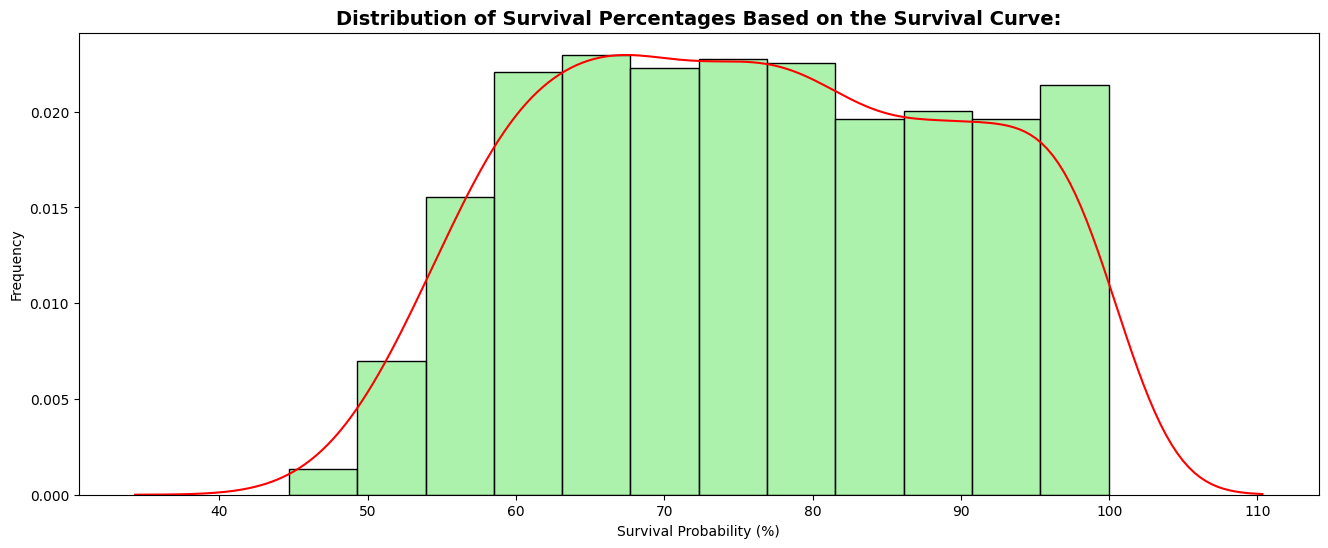

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (16, 6))
sns.histplot(survival_curve['survival_probability%']*100, stat = 'density', color = 'lightgreen', edgecolor = 'black')
sns.kdeplot(survival_curve['survival_probability%']*100, color = 'red')
plt.xlabel('Survival Probability (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Survival Percentages Based on the Survival Curve:', fontweight = 'bold', fontsize = 14)
plt.show()

# Next Step:

Merging Survival Probabilities from the Survival Curve onto the Original DataFrame:

* Will Feature Engineer a `dtime_yrs` column in the `df` DataFrame by converting 'dtime' from Days to Years, then will Merge `survival_probability%` from the `survival_curve` DataFrame into `df` by finding the closest `time_yrs` from *survival_curve* to `dtime_yrs` from *df*, for each patient.

In [ ]:
df['dtime_yrs'] = df['dtime'] / 365
df.head(4)

,pid,year,age,meno,size,grade,nodes,pgr,er,hormon,chemo,rtime,recur,dtime,death,status,rtime_yrs,treatment,dtime_yrs
0,1,1992,74,1,<=20,3,0,35,291,0,0,1799,0,1799,0,0,4.925394,drugA,4.928767
1,2,1984,79,1,20-50,3,0,36,611,0,0,2828,0,2828,0,0,7.742642,placebo,7.747945
2,3,1983,44,0,<=20,2,0,138,0,0,0,6012,0,6012,0,0,16.459959,drugA,16.471233
3,4,1985,70,1,20-50,3,0,0,12,0,0,2624,0,2624,0,0,7.184120,placebo,7.189041


In [ ]:
# Integrating Survival Probabilities into "df"

df_sorted = df.sort_values(by = 'dtime_yrs').reset_index(drop = True)
survival_curve_sorted = survival_curve.sort_values(by = 'time_yrs').reset_index(drop = True)

df_merged = pd.merge_asof(df_sorted, survival_curve_sorted[['time_yrs', 'survival_probability%']], left_on = 'dtime_yrs', right_on = 'time_yrs', direction = 'nearest')
df_merged.drop(columns = ['time_yrs'], inplace = True)
df = df_merged.sort_values(by = 'pid').reset_index(drop = True)

print("Updated df DataFrame with merged survival probabilities:\n")
display(df.sample(8))

Updated df DataFrame with merged survival probabilities:



,pid,year,age,meno,size,grade,nodes,pgr,er,hormon,chemo,rtime,recur,dtime,death,status,rtime_yrs,treatment,dtime_yrs,survival_probability%
1226,1238,1992,41,0,<=20,3,5,40,35,0,1,2928,0,2928,0,0,8.016427,drugA,8.021918,0.562714
2125,2144,1991,32,0,20-50,3,19,148,24,0,0,348,1,907,1,1,0.952772,placebo,2.484932,0.759549
1112,1123,1986,68,1,20-50,3,1,29,203,0,0,4013,0,4013,0,0,10.986995,drugA,10.994521,0.510569
1640,1656,1991,50,1,20-50,3,2,140,64,1,0,38,1,437,1,1,0.104038,drugA,1.197260,0.891873
1779,1797,1985,55,1,<=20,3,2,58,80,1,0,3582,1,4216,0,0,9.806982,placebo,11.550685,0.496662
1751,1769,1985,65,1,<=20,3,13,44,184,0,0,137,1,722,1,1,0.375086,placebo,1.978082,0.802355
2541,2565,1989,53,0,20-50,2,2,0,0,0,1,615,1,826,1,1,1.683778,placebo,2.263014,0.777724
393,399,1983,42,0,20-50,3,0,0,0,0,0,5414,0,5414,0,0,14.822724,placebo,14.832877,0.446942


In [ ]:
df[['pid', 'year', 'meno', 'hormon', 'chemo', 'grade', 'recur', 'death', 'status']] = df[['pid', 'year', 'meno', 'hormon', 'chemo', 'grade', 'recur', 'death', 'status']].astype(object)
print(df.info())

df.to_csv('df_final.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pid                    2982 non-null   object 
 1   year                   2982 non-null   object 
 2   age                    2982 non-null   int64  
 3   meno                   2982 non-null   object 
 4   size                   2982 non-null   object 
 5   grade                  2982 non-null   object 
 6   nodes                  2982 non-null   int64  
 7   pgr                    2982 non-null   int64  
 8   er                     2982 non-null   int64  
 9   hormon                 2982 non-null   object 
 10  chemo                  2982 non-null   object 
 11  rtime                  2982 non-null   int64  
 12  recur                  2982 non-null   object 
 13  dtime                  2982 non-null   int64  
 14  death                  2982 non-null   object 
 15  stat

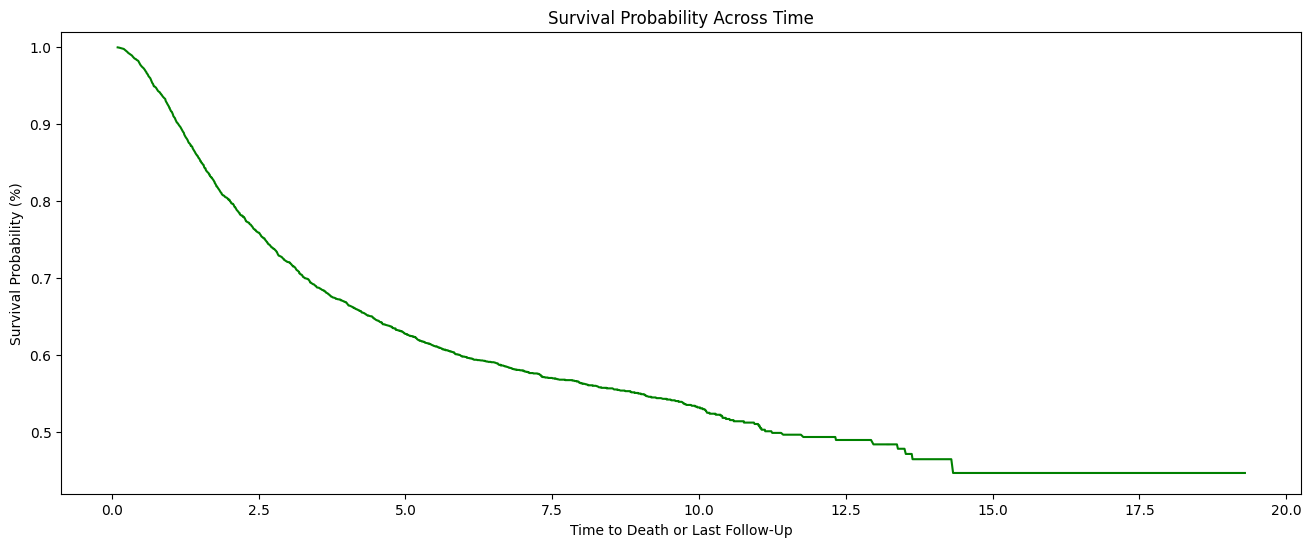

In [ ]:
# Let's take a Better look!

# df['survival_probability%'].min(), df['survival_probability%'].max()

plt.figure(figsize = (16, 6))
sns.lineplot(x = df['dtime_yrs'], y = df['survival_probability%'], color = 'green')
plt.xlabel('Time to Death or Last Follow-Up')
plt.ylabel('Survival Probability (%)')
plt.ylim(0.42, 1.02)
plt.title('Survival Probability Across Time')
plt.show()

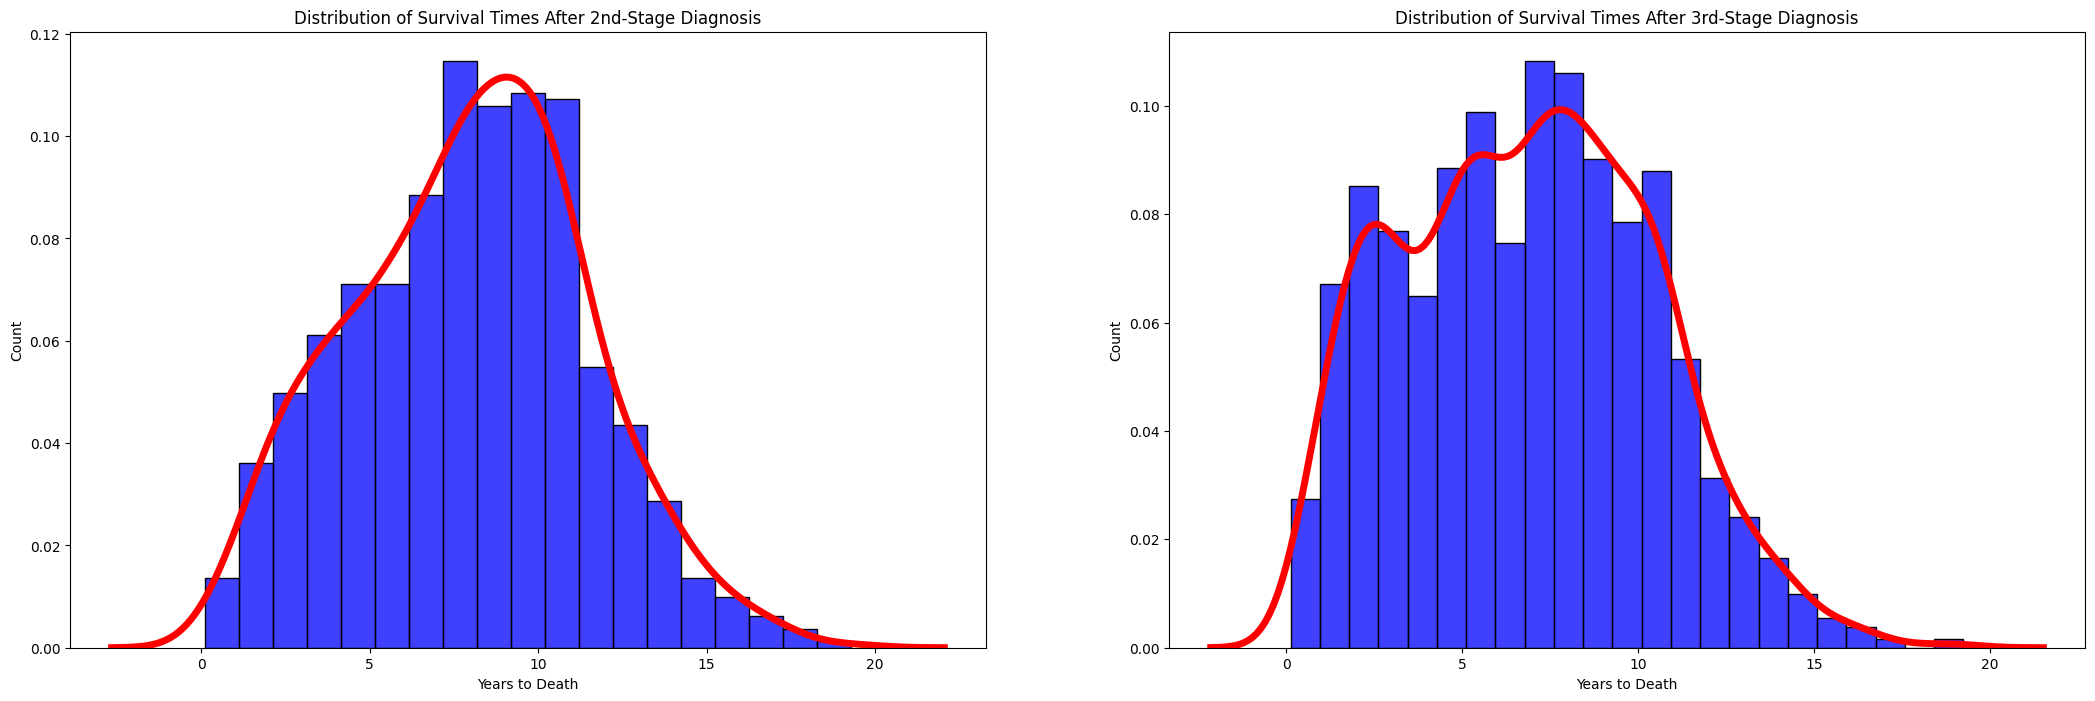

In [ ]:
plt.figure(figsize = (26, 8))

plt.subplot(1, 2, 1)
sns.histplot(df[df['grade'] == 2]['dtime_yrs'], color = 'blue', stat = 'density', edgecolor = 'black')
sns.kdeplot(df[df['grade'] == 2]['dtime_yrs'], color = 'red', linewidth = 5)
plt.title('Distribution of Survival Times After 2nd-Stage Diagnosis')
plt.xlabel('Years to Death')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df[df['grade'] == 3]['dtime_yrs'], color = 'blue', stat = 'density', edgecolor = 'black')
sns.kdeplot(df[df['grade'] == 3]['dtime_yrs'], color = 'red', linewidth = 5)
plt.title('Distribution of Survival Times After 3rd-Stage Diagnosis')
plt.xlabel('Years to Death')
plt.ylabel('Count')

plt.show()

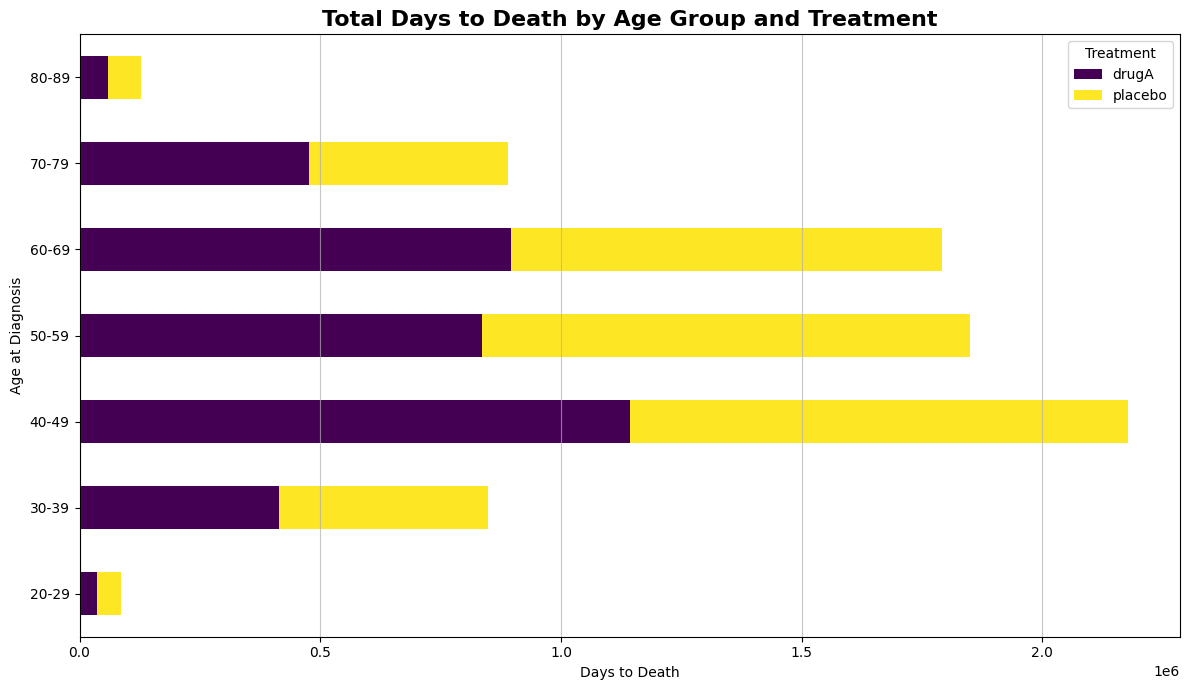

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Creating Age Groups (Bins)
df['age_group'] = pd.cut(df['age'], bins = range(20, df['age'].max() + 10, 10),
                         right = False, labels = [f'{i}-{i+9}' for i in range(20, df['age'].max() + 10, 10) if i < df['age'].max()])

# Calculating the Sum of 'dtime' for each age Group and Treatment
pivoted_data = df.groupby(['age_group', 'treatment'])['dtime'].sum().unstack(fill_value = 0)

# Plotting the Horizontal Stacked Bar Chart
fig, ax = plt.subplots(figsize = (12, 7))
pivoted_data.plot(kind = 'barh', stacked = True, ax = ax, cmap = 'viridis')

plt.title('Total Survival Time by Age Group and Treatment', fontweight = 'bold', fontsize = 16)
plt.xlabel('Days to Death')
plt.ylabel('Age at Diagnosis')
plt.legend(title = 'Treatment')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.7)
plt.tight_layout()
plt.show() # Both Forms of Treatment Appear to be Equally Productive

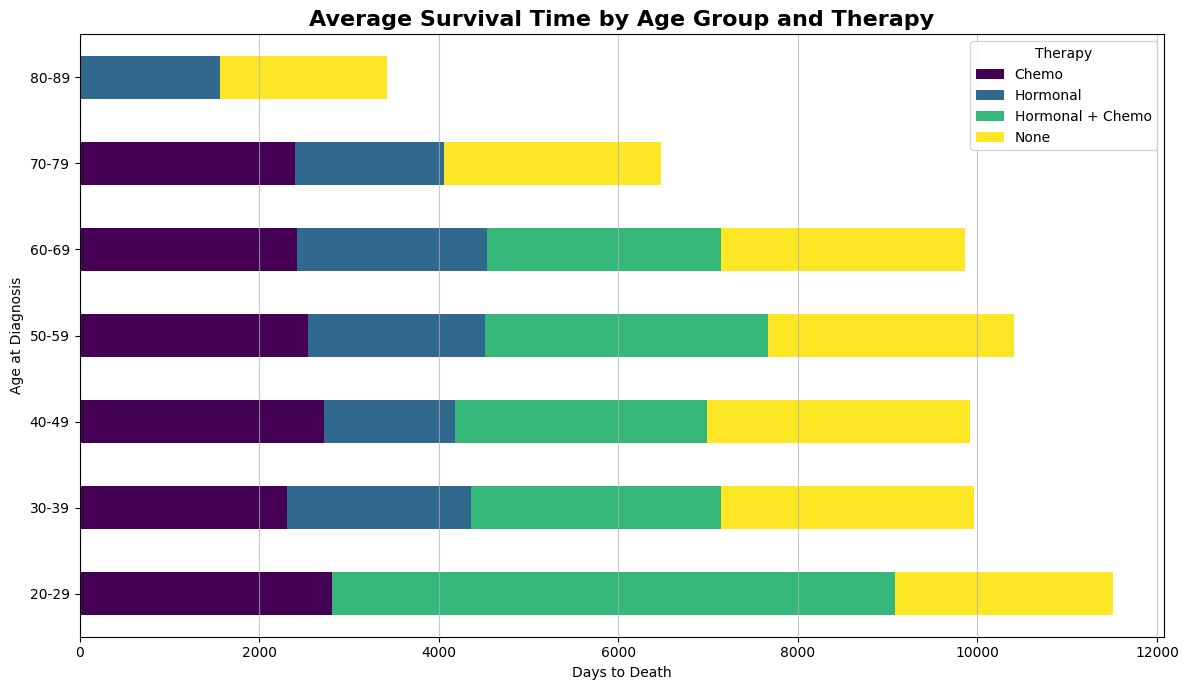

In [ ]:
pd.set_option('display.max_columns', None)

df2 = df.copy()

df2['hormon'] = df2['hormon'].map({0: 'Not Hormonal', 1: 'Hormonal'})
df2['chemo'] = df2['chemo'].map({0: 'Not Chemo', 1: 'Chemo'})

# Defining Better Names for Therapy Combinations
conditions = [
    (df2['hormon'] == 'Hormonal') & (df2['chemo'] == 'Chemo'),
    (df2['hormon'] == 'Hormonal') & (df2['chemo'] == 'Not Chemo'),
    (df2['hormon'] == 'Not Hormonal') & (df2['chemo'] == 'Chemo'),
    (df2['hormon'] == 'Not Hormonal') & (df2['chemo'] == 'Not Chemo')
]

# Defining Choices for the Therapy column based on Conditions
choices = [
    'Hormonal + Chemo',
    'Hormonal',
    'Chemo',
    'None'
]

# Using "np.select" to Apply the Conditional Mapping
df2['therapy'] = np.select(conditions, choices, default = 'Unknown')

pivoted_data2 = df2.groupby(['age_group', 'therapy'])['dtime'].mean().unstack(fill_value = 0) # Why Mean? Will elaborate on it, later, as a Sum was not giving the Optimal picture here

# Plotting the Horizontal Stacked Bar Chart
fig, ax = plt.subplots(figsize = (12, 7))
pivoted_data2.plot(kind = 'barh', stacked = True, ax = ax, cmap = 'viridis')

plt.title('Average Survival Time by Age Group and Therapy', fontweight = 'bold', fontsize = 16)
plt.xlabel('Days to Death')
plt.ylabel('Age at Diagnosis')
plt.legend(title = 'Therapy')
plt.grid(axis = 'x', linestyle = '-', alpha = 0.7)
plt.tight_layout()
plt.show()

# Interesting: No Therapy yielded the Longest Survival Times! But, that might be because the Disease Diagnosed was not as Dangerous anyway?
# Upon further Analysis & from a Different Angle, it was Deemed that since this is a Sum, the people who received No Therapy were much Higher in Amount, so thus Naturally yielded a Higher Sum of Survival Days